# Import

In [25]:
# Import necessary libraries
from pyhgf.model import Network
from scipy.stats import halfnorm, norm
import copy
import pandas as pd
import time
import numpy as np
from environement import generate_observations
from voting import get_votes
import altair as alt
import matplotlib.pyplot as plt
# Import JAX and related modules
from jax import random, vmap
from jax.tree_util import Partial
from functools import partial as Partial


# Parameters

In [26]:
# Parameters for the simulation
n_candidates = 6  # Number of candidates
n_preferences = 4  # Number of preferences per candidate
n_agents = 50  # Number of agents in the simulation
simulations = 500  # Number of simulations

# Generate observations using the generate_observations function
input_data = generate_observations(n_nodes=n_preferences, n_steps=1000, scenario=1)

# Generate tonic volatilities for agents using a normal distribution
tonic_volatilities = np.random.normal(-3.0, 1.0, n_agents)


# Generate candidats

In [27]:
# Generate candidates with preferences
# Each candidate has a list of preferences, each preference is a tuple (mu, sigma)
extreme_indices = np.random.choice(n_candidates, replace=False)
candidates = []
for i in range(n_candidates):
    preferences = []
    mu_sigma = 1
    sigma_scale = 1
    for pref in range(n_preferences):
        mu = norm.rvs(2, mu_sigma)
        sigma = halfnorm.rvs(scale=sigma_scale)
        mu_sigma_tuple = (np.float64(mu), np.float64(sigma))
        preferences.append(mu_sigma_tuple)
    candidates.append(tuple(preferences))
print("Content of candidates:")
print(candidates)  # candidates is a list of tuples, each tuple contains preferences formalized as (mu, sigma) pairs of distributions

Content of candidates:
[((np.float64(2.9239714278716225), np.float64(1.8887237159105552)), (np.float64(1.4806981559609873), np.float64(0.1966927698722249)), (np.float64(0.14395667313054594), np.float64(1.3768970417896995)), (np.float64(1.962924505832527), np.float64(0.2616343777027056))), ((np.float64(1.0139858573002767), np.float64(1.422939640543623)), (np.float64(3.1933058792174354), np.float64(0.3825288583789756)), (np.float64(1.7605878243154676), np.float64(0.5466702424899409)), (np.float64(1.2288247075498475), np.float64(1.3027832768210437))), ((np.float64(1.120203654629581), np.float64(0.17968349257726401)), (np.float64(2.008704329651233), np.float64(1.9481737788572924)), (np.float64(2.240946881999318), np.float64(1.5439688984752336)), (np.float64(2.6354601088299123), np.float64(1.1864165297170102))), ((np.float64(2.5220186105991496), np.float64(0.42950584473677855)), (np.float64(1.325675252797616), np.float64(0.21056645731155899)), (np.float64(0.5281409322823785), np.float64(0.0

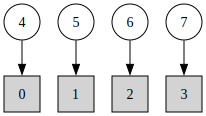

In [28]:
# Create agent preferences dynamically based on n_preferences
network = Network()

# Add binary-state nodes to the network
network.add_nodes(kind="binary-state", n_nodes=n_preferences)

# Add value nodes for each binary-state node
for i in range(n_preferences):
    network.add_nodes(value_children=i)

# Plot the network
network.plot_network()

# Generate agents

In [29]:
# Assuming get_votes and other necessary functions are defined elsewhere

results = []
simulation_number = 0

while simulations > 0:
    # Initialize random keys for JAX
    key = random.PRNGKey(int(time.time()))
    keys = random.split(key, n_agents)

    # Setup and vectorize the get_votes function for the first round
    get_votes_fn = Partial(
        get_votes,
        network=copy.deepcopy(network),
        input_data=input_data,
        n_preferences=n_preferences,
        candidates=candidates,
    )
    vmap_get_votes_fn = vmap(get_votes_fn)
    attribute, nodes_traje = vmap_get_votes_fn(tonic_volatilities, keys)
    votes_1st_round = attribute[-1]["votes"]
    counts = np.bincount(votes_1st_round)

    # Calculate proportions for the first round
    if len(counts) == 0 or sum(counts) == 0:
        proportions_1st = []
    else:
        proportions_1st = [v / sum(counts) for v in counts]

    # Check if there are at least two candidates for the second round
    if len(counts) >= 2:
        top2 = np.argsort(counts)[-2:][::-1]
        top_two_indices = top2
        top_two_candidates = [candidates[i] for i in top_two_indices]

        # Setup and vectorize the get_votes function for the second round
        get_votes_fn_2nd = Partial(
            get_votes,
            network=copy.deepcopy(network),
            input_data=input_data,
            n_preferences=n_preferences,
            candidates=top_two_candidates,
        )
        vmap_get_votes_fn_2nd = vmap(get_votes_fn_2nd)
        attribute2, nodes_traje2 = vmap_get_votes_fn_2nd(tonic_volatilities, keys)
        votes_2nd_round = attribute2[-1]["votes"]
        counts_2nd = np.bincount(votes_2nd_round)

        # Calculate proportions for the second round
        if len(counts_2nd) == 0 or sum(counts_2nd) == 0:
            proportions_2nd = []
        else:
            proportions_2nd = [v / sum(counts_2nd) for v in counts_2nd]
    else:
        top_two_candidates = []
        proportions_2nd = []

    # Store results for this simulation
    simulation_number += 1
    results.append({
        "simulation_number": simulation_number,
        "first_round": {
            "proportions": proportions_1st,
            "candidates": candidates
        },
        "second_round": {
            "proportions": proportions_2nd,
            "candidates": top_two_candidates
        }
    })
    simulations -= 1

# Normalize the data for the DataFrame
normalized_data = []
for result in results:
    simulation_number = result["simulation_number"]
    # Add first round data
    for candidate, proportion in zip(result["first_round"]["candidates"], result["first_round"]["proportions"]):
        normalized_data.append({
            "simulation_number": simulation_number,
            "round": "first",
            "candidate": candidate,
            "proportion": proportion
        })
    # Add second round data
    for candidate, proportion in zip(result["second_round"]["candidates"], result["second_round"]["proportions"]):
        normalized_data.append({
            "simulation_number": simulation_number,
            "round": "second",
            "candidate": candidate,
            "proportion": proportion
        })

# Create a DataFrame from the normalized data
final_df = pd.DataFrame(normalized_data)

KeyboardInterrupt: 

# Plots

In [23]:
final_df['candidate'] = final_df['candidate'].astype('category')
final_df['candidate_id'] = final_df['candidate'].cat.codes
# split the DataFrame into first and second rounds
df_first_round = pd.DataFrame(final_df[final_df['round'] == 'first'])
df_second_round = pd.DataFrame(final_df[final_df['round'] == 'second'])

In [24]:
# Convert 'candidate' column to categorical data type
final_df['candidate'] = final_df['candidate'].astype('category')

# Assign a unique numerical identifier to each candidate
final_df['candidate_id'] = final_df['candidate'].cat.codes

# Split the DataFrame into first and second rounds
df_first_round = pd.DataFrame(final_df[final_df['round'] == 'first'])
df_second_round = pd.DataFrame(final_df[final_df['round'] == 'second'])

# Make a copy of the original DataFrame for the first round
df = df_first_round.copy()

# Get sorted list of unique candidate IDs
all_candidates = sorted(df['candidate_id'].unique())

# Define a categorical color scale for consistent color mapping
color_scale = alt.Scale(domain=all_candidates, scheme='category20b')

# Define interactive highlight on mouseover
highlight = alt.selection(type='single', fields=['candidate_id'], on='mouseover', empty='all')

# Create the area chart for vote proportions in the first round
chart_first = alt.Chart(df[df['round'] == 'first']).mark_area(opacity=0.85).encode(
    x=alt.X('simulation_number:N', title='Simulation Number', axis=alt.Axis(labelAngle=0)),
    y=alt.Y('proportion:Q', stack='center', title='Vote Proportion', axis=alt.Axis(format='.0%')),
    color=alt.Color('candidate_id:N', scale=color_scale, legend=alt.Legend(title='Candidate')),
    opacity=alt.condition(highlight, alt.value(1), alt.value(0.2)),  # Highlight selected candidate
    tooltip=[
        alt.Tooltip('candidate_id:N', title='Candidate'),
        alt.Tooltip('proportion:Q', title='Proportion', format='.1%'),
        alt.Tooltip('simulation_number:N', title='Simulation')
    ]
).add_selection(
    highlight
).properties(
    width=700,
    height=350,
    title="Evolution of Vote Proportions – First Round"
).configure_axis(
    grid=True,
    gridColor='lightgray',
    gridDash=[2, 2]
).configure_view(
    stroke=None
).configure_title(
    fontSize=18,
    anchor='start',
    font='Helvetica'
)

# Display the chart
chart_first


/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_99923/260613376.py:21: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use 'selection_point()' or 'selection_interval()' instead.
These functions also include more helpful docstrings.
  highlight = alt.selection(type='single', fields=['candidate_id'], on='mouseover', empty='all')
/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_99923/260613376.py:34: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use add_params instead.
  ).add_selection(


alt.Chart(...)

In [16]:
import pandas as pd
import altair as alt

# Assuming df_second_round is already defined and filtered for the second round

# Make a copy of the DataFrame for the second round
df = df_second_round.copy()

# Get sorted list of unique candidate IDs in the second round
all_candidates = sorted(df['candidate_id'].unique())

# Define a categorical color scale for consistent color mapping
color_scale = alt.Scale(domain=all_candidates, scheme='category20b')

# Define interactive highlight on mouseover
highlight = alt.selection(type='single', fields=['candidate_id'], on='mouseover', empty='all')

# Create the area chart for vote proportions in the second round
chart_second = alt.Chart(df).mark_area(opacity=0.85).encode(
    x=alt.X('simulation_number:N', title='Simulation Number', axis=alt.Axis(labelAngle=0)),
    y=alt.Y('proportion:Q', stack='center', title='Vote Proportion', axis=alt.Axis(format='.0%')),
    color=alt.Color('candidate_id:N', scale=color_scale, legend=alt.Legend(title='Candidate')),
    opacity=alt.condition(highlight, alt.value(1), alt.value(0.2)),  # Highlight selected candidate
    tooltip=[
        alt.Tooltip('candidate_id:N', title='Candidate'),
        alt.Tooltip('proportion:Q', title='Proportion', format='.1%'),
        alt.Tooltip('simulation_number:N', title='Simulation')
    ]
).add_selection(
    highlight
).properties(
    width=700,
    height=350,
    title="Evolution of Vote Proportions – Second Round"
).configure_axis(
    grid=True,
    gridColor='lightgray',
    gridDash=[2, 2]
).configure_view(
    stroke=None
).configure_title(
    fontSize=18,
    anchor='start',
    font='Helvetica'
)

# Display the chart
chart_second


/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_99923/4203215999.py:16: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use 'selection_point()' or 'selection_interval()' instead.
These functions also include more helpful docstrings.
  highlight = alt.selection(type='single', fields=['candidate_id'], on='mouseover', empty='all')
/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_99923/4203215999.py:29: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use add_params instead.
  ).add_selection(


alt.Chart(...)

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_99923/2405435442.py:62: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


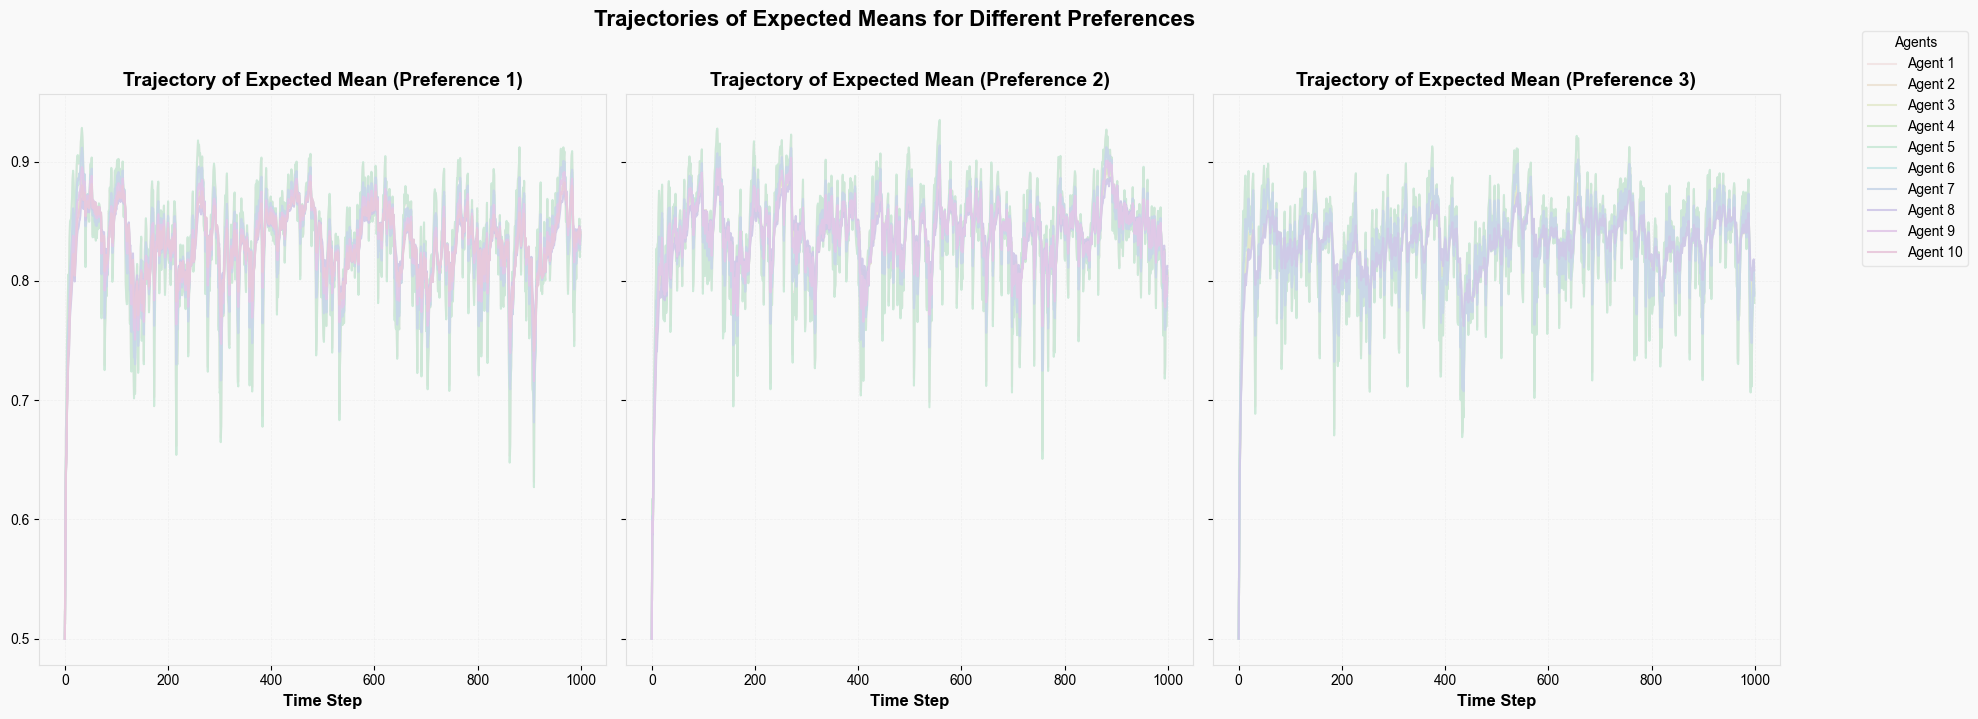

In [18]:

# Définir les paramètres globaux pour la police
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Définir les styles de ligne (tous des traits pleins)
line_styles = ["-"] * 10  # Tous les styles de ligne sont des traits pleins

# Créer une figure avec 3 sous-graphiques côte à côte
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True, facecolor='#f9f9f9')

# Liste des préférences et leurs indices correspondants
preferences = [0, 1, 2]  # Indices pour pref 1, pref 2, pref 4
pref_labels = ['Preference 1', 'Preference 2', 'Preference 3']

# Générer une palette de couleurs pastel
def generate_pastel_colors(n):
    pastel_colors = []
    for i in range(n):
        hue = i / n  # Distribuer les teintes uniformément
        saturation = 0.4  # Saturation légèrement réduite pour des couleurs encore plus pastel
        lightness = 0.85  # Luminosité plus élevée pour des couleurs très claires
        rgb = colorsys.hls_to_rgb(hue, lightness, saturation)
        pastel_colors.append(rgb)
    return pastel_colors

pastel_colors = generate_pastel_colors(n_agents)

for idx, pref in enumerate(preferences):
    ax = axes[idx]
    ax.set_facecolor('#f9f9f9')  # Fond du graphique légèrement plus clair
    for n_agents in range(n_agents):
        # Utiliser la couleur pastel correspondante
        color = pastel_colors[n_agents]
        # Définir la transparence
        alpha = 0.4 + 0.6 * (n_agents / (n_agents+1))  # Safe range: 0.4–1.0

        ax.plot(
            nodes_traje[pref]["expected_mean"][n_agents],
            label=f'Agent {n_agents + 1}' if idx == 0 else "",
            color=color,
            linestyle=line_styles[n_agents % len(line_styles)],
            linewidth=1.5,  # Lignes un peu plus fines
            alpha=alpha
        )
    ax.set_xlabel('Time Step', fontsize=12, fontweight='bold')
    ax.set_title(f'Trajectory of Expected Mean ({pref_labels[idx]})', fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4, color='#e0e0e0', linewidth=0.5)  # Grille très subtile

    # Ajouter une bordure subtile autour de chaque sous-graphique
    for spine in ax.spines.values():
        spine.set_edgecolor('#e0e0e0')  # Couleur de bordure très claire
        spine.set_linewidth(0.8)

# Ajouter une légende commune
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.1, 1), title="Agents", facecolor='#f9f9f9', edgecolor='#e0e0e0')

# Ajouter un titre global
fig.suptitle('Trajectories of Expected Means for Different Preferences', fontsize=16, fontweight='bold', y=1.02)

# Ajuster les marges et l'espacement
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Ajustement pour le titre global

plt.show()


# Next steps https://refactoring.guru/refactoring

Structure :

Classe Agent (ou Electeur / Candidat) : Contient les attributs propres à chaque agent (préférences, historique de vote, état HGF, etc.) et des méthodes pour leur comportement (décider de voter, mettre à jour ses croyances).

Classe Environnement : Gère les règles globales de la simulation. Elle contient la liste de tous les agents, les résultats des élections, les informations disponibles, et fait avancer la simulation étape par étape.

Avantage : Ce pattern garantit que la logique de chaque agent reste simple et localisée. L'environnement s'occupe de la "vie sociale" des agents, comme l'organisation des votes et la diffusion des informations.

2. Le pattern "Strategy" (Stratégie)
Ce pattern est parfait pour modéliser les différents modes de prise de décision de vos agents, comme la "Voie de la solution" que vous avez mentionnée (décision modèle-basé vs. modèle-libre).

Structure :

Interface DecisionStrategy : Une interface qui définit une méthode choisir_candidat().

Classes concrètes : Des implémentations de l'interface, comme ModeleBaseStrategy et ModeleLibreStrategy. Chacune contient sa propre logique de décision.

Classe Agent : Contient une référence à une instance de DecisionStrategy.

Avantage : Ce pattern permet à un agent de changer de stratégie de décision à la volée. Par exemple, un agent peut commencer avec une stratégie "modèle-libre" (voter par habitude) puis passer à une stratégie "modèle-basée" s'il perçoit de nouvelles informations importantes et veut prendre le temps d'évaluer les conséquences.

3. Le pattern "Observer" (Observateur)
Idéal pour gérer la "Voie de l'environnement" et la "Voie du problème" concernant l'influence sociale et la confiance.

Structure :

Interface Sujet (Subject) : Un objet qui peut être "observé" (par exemple, un média, un candidat, ou un "leader d'opinion"). Il maintient une liste d'observateurs.

Interface Observateur (Observer) : Un agent qui s'abonne aux notifications du sujet.

Implémentation : Lorsque l'état du sujet change (par exemple, un candidat publie un nouveau programme), il notifie tous ses observateurs.

Avantage : Ce pattern gère élégamment la diffusion de l'information. Un agent peut décider de ne s'abonner qu'à des sujets en qui il a confiance. C'est le mécanisme de base pour simuler des phénomènes comme les chambres d'écho. Si un agent perd confiance en un sujet, il se "désabonne" simplement.

Pour votre système de vote, la meilleure approche est une combinaison de ces trois patterns.

Utilisez le pattern Agent-Environnement comme votre structure de base. C'est le squelette de votre simulation.

Dans la classe Agent (ou Electeur), implémentez le pattern Strategy pour gérer la décision modèle-basé vs. modèle-libre.

Utilisez le pattern Observer pour modéliser la circulation des informations entre les agents et les sources (candidats, médias, etc.).

### Phase 1: Define the Core Agent Behavior (Voie de la solution & Voie du problème)

Start by building the fundamental logic for a single agent. This will be the backbone of your simulation.

1.  **Define a Simple Decision-Making Algorithm (Voie de la solution):**
    * **Implement Model-based vs. Model-free Decision-making.** This is the most crucial choice. Begin with a simple, baseline agent that uses one of these methods.
        * **Model-free:** The agent has a simple, hard-coded preference or habit. It votes for a specific candidate based on a pre-defined value. This is a great starting point because it's easy to code.
        * **Model-based:** The agent evaluates candidates by "simulating" the outcomes. For example, it could have a simple rule like: *Candidate A's policy on X will lead to outcome Y, which has value Z.* This adds a layer of complexity and allows for more dynamic behavior.
    * **Implement Exploration-Exploitation Trade-off.** Once you have a basic decision algorithm, add a variable that controls an agent's willingness to explore. A "dogmatic" agent has a low exploration value and sticks to its existing knowledge, while an "open-minded" agent has a higher value and will actively seek out information on new candidates.

2.  **Add Core Individual Preferences (Voie du problème):**
    * **Implement a Value Function.** Give each agent a unique set of preferences. For instance, Agent 1 values economic stability highly, while Agent 2 values social welfare. The **value function** ($V_a$) for an agent (*a*) is a way to calculate the total value of a candidate. For example, $V_a = w_1 \times \text{economic_policy_score} + w_2 \times \text{social_policy_score}$, where $w_1$ and $w_2$ are the agent's weights (preferences).
    * **Integrate Temporal Discounting.** Add a parameter that dictates how much an agent prioritizes immediate benefits over long-term promises. An agent with a high discount rate will prefer a candidate who promises quick results, even if the long-term plan is less beneficial.

### Phase 2: Add Social and Environmental Context (Voie de l'environnement & Social Voie du problème)

Once your individual agents are making decisions, introduce social elements and environmental factors that will make your simulation more realistic.

1.  **Integrate Social Factors (Voie du problème):**
    * **Implement Social Value Functions.** Expand your agents' value functions to include social considerations. For example, an agent's total value could be a combination of its personal benefit and a factor for group well-being.
    * **Implement Trust.** Create a variable for each agent's trust in different information sources (e.g., news outlets, other agents). An agent with low trust in a source will discount or ignore information from it, even if that information is factually correct.

2.  **Introduce Environmental and Historical Effects (Voie de l'environnement):**
    * **Simulate Path Dependence.** Use a variable to track an agent's past experiences. For example, an agent who had a negative experience with Candidate A in the past could have a permanent negative bias against them, regardless of new information.
    * **Create Agent Interactions.** This is where your simulation truly becomes multi-agent. Allow agents to influence each other. For example, implement a mechanism where agents can share information or influence the trust levels of others. This is the foundational step for creating emergent behaviors like echo chambers.

### Phase 3: Observe Emergent Behavior (All Routes Combined)

Once the foundational elements are in place, you can focus on running the simulation and observing how these different rules interact.

1.  **Simulate Theory of Mind.** This is an advanced concept that emerges from agent interactions. You can observe how an agent's decision-making changes based on its knowledge or assumptions about what other agents are doing. This isn't something you "code" directly but rather something that emerges from the simulation's dynamics. For example, an agent might vote for a certain candidate because it *predicts* that its social group will do the same.
2.  **Observe Echo Chambers.** This is another emergent phenomenon. With the social interaction and trust rules you implemented in Phase 2, you can run the simulation and see if agents naturally form isolated groups with similar beliefs. You could visualize this by plotting the agents' belief systems over time and watching them cluster together.